In [388]:
import numpy as np
import pandas as pd

In [389]:
df=pd.read_csv("spam.csv",encoding="latin-1")

In [390]:
df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [391]:
df.shape

(5572, 5)

In [392]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   v1          5572 non-null   object
 1   v2          5572 non-null   object
 2   Unnamed: 2  50 non-null     object
 3   Unnamed: 3  12 non-null     object
 4   Unnamed: 4  6 non-null      object
dtypes: object(5)
memory usage: 217.8+ KB


In [393]:
df.drop(["Unnamed: 2" ,"Unnamed: 3" ,"Unnamed: 4"],axis=1,inplace=True)

In [394]:
df.rename(columns={"v1":"target","v2":"text"},inplace=True)

In [395]:
df.head(5)

,target,text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [396]:
from sklearn.preprocessing import LabelEncoder

In [397]:
encoder=LabelEncoder()
df["target"]=encoder.fit_transform(df[["target"]])

C:\Users\iluki\anaconda3\Lib\site-packages\sklearn\preprocessing\_label.py:110: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


In [398]:
df

,target,text
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."
...,...,...
5567,1,This is the 2nd time we have tried 2 contact u...
5568,0,Will Ì_ b going to esplanade fr home?
5569,0,"Pity, * was in mood for that. So...any other s..."
5570,0,The guy did some bitching but I acted like i'd...


In [399]:
df.duplicated().sum()

np.int64(403)

In [400]:
df.drop_duplicates(inplace=True)

In [401]:
df.shape

(5169, 2)

In [402]:
x=df["target"].value_counts()

In [403]:
import matplotlib.pyplot as plt
import seaborn as sns

([<matplotlib.patches.Wedge at 0x15b14b7dbd0>,
 [Text(-1.014499732282844, 0.4251944181172162, '0'),
  Text(1.0144998708287172, -0.42519408755122207, '1')],
 [Text(-0.5533634903360967, 0.2319242280639361, '87.37%'),
  Text(0.553363565906573, -0.231924047755212, '12.63%')])

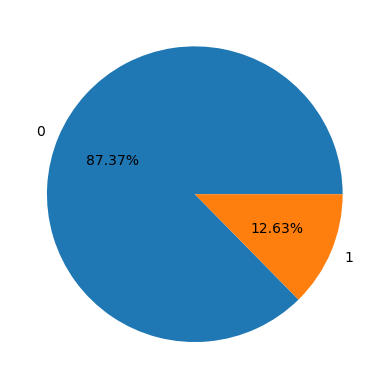

In [404]:
plt.pie(x.values,labels=x.index,autopct="%0.2f%%")

In [405]:
import nltk

In [406]:
nltk.download('punkt_tab')
  

[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\iluki\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [407]:
df["num_char"]=df["text"].apply(len)

In [408]:
df["num_words"]=df["text"].apply(lambda x :len(nltk.word_tokenize(x)))


In [409]:
df["num_sen"]=df["text"].apply(lambda x :len(nltk.sent_tokenize(x)))

In [410]:
df

,target,text,num_char,num_words,num_sen
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2
1,0,Ok lar... Joking wif u oni...,29,8,2
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2
3,0,U dun say so early hor... U c already then say...,49,13,1
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1
...,...,...,...,...,...
5567,1,This is the 2nd time we have tried 2 contact u...,161,35,4
5568,0,Will Ì_ b going to esplanade fr home?,37,9,1
5569,0,"Pity, * was in mood for that. So...any other s...",57,15,2
5570,0,The guy did some bitching but I acted like i'd...,125,27,1


In [411]:
df.describe()

,target,num_char,num_words,num_sen
count,5169.000000,5169.000000,5169.000000,5169.000000
mean,0.126330,78.977945,18.455794,1.965564
std,0.332253,58.236293,13.324758,1.448541
min,0.000000,2.000000,1.000000,1.000000
25%,0.000000,36.000000,9.000000,1.000000
50%,0.000000,60.000000,15.000000,1.000000
75%,0.000000,117.000000,26.000000,2.000000
max,1.000000,910.000000,220.000000,38.000000


In [412]:
df[df["target"]==0].describe()

,target,num_char,num_words,num_sen
count,4516.0,4516.000000,4516.000000,4516.000000
mean,0.0,70.459256,17.123782,1.820195
std,0.0,56.358207,13.493970,1.383657
min,0.0,2.000000,1.000000,1.000000
25%,0.0,34.000000,8.000000,1.000000
50%,0.0,52.000000,13.000000,1.000000
75%,0.0,90.000000,22.000000,2.000000
max,0.0,910.000000,220.000000,38.000000


In [413]:
df[df["target"]==1].describe()

,target,num_char,num_words,num_sen
count,653.0,653.000000,653.000000,653.000000
mean,1.0,137.891271,27.667688,2.970904
std,0.0,30.137753,7.008418,1.488425
min,1.0,13.000000,2.000000,1.000000
25%,1.0,132.000000,25.000000,2.000000
50%,1.0,149.000000,29.000000,3.000000
75%,1.0,157.000000,32.000000,4.000000
max,1.0,224.000000,46.000000,9.000000


<Axes: >

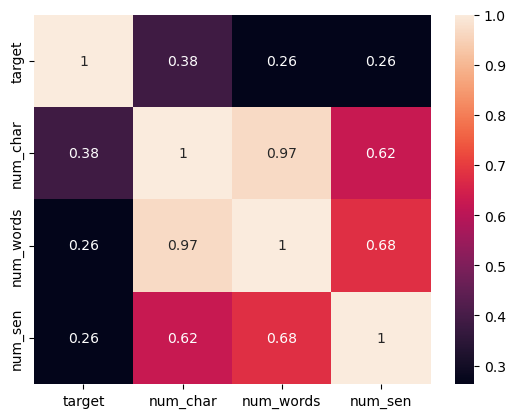

In [414]:
sns.heatmap(df.corr(numeric_only=True),annot=True)

In [415]:
from nltk.corpus import stopwords
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\iluki\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [416]:
from nltk.stem.porter import PorterStemmer
ps=PorterStemmer()

In [417]:
import string

In [418]:
def trans(text):
    text=text.lower()
    text=nltk.word_tokenize(text)
    y=[]
    for i in text:
        if i.isalnum():
            y.append(i)
    text=y[:]
    y.clear()
    for i in text:
        if i not in stopwords.words('english') and i not in string.punctuation:
            y.append(i)
    text=y[:]
    y.clear()
    for i in text:
        y.append(ps.stem(i))
    return y
    

In [419]:
trans("hi angali have you a liked  $$ the gift .is it beautiful")

['hi', 'angali', 'like', 'gift', 'beauti']

In [420]:
df["transform_text"]=df["text"].apply(trans)

In [421]:
df["transform_text"]=df["transform_text"].apply(lambda x : " ".join(x))

In [422]:
df

,target,text,num_char,num_words,num_sen,transform_text
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2,go jurong point crazi avail bugi n great world...
1,0,Ok lar... Joking wif u oni...,29,8,2,ok lar joke wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2,free entri 2 wkli comp win fa cup final tkt 21...
3,0,U dun say so early hor... U c already then say...,49,13,1,u dun say earli hor u c alreadi say
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1,nah think goe usf live around though
...,...,...,...,...,...,...
5567,1,This is the 2nd time we have tried 2 contact u...,161,35,4,2nd time tri 2 contact u pound prize 2 claim e...
5568,0,Will Ì_ b going to esplanade fr home?,37,9,1,b go esplanad fr home
5569,0,"Pity, * was in mood for that. So...any other s...",57,15,2,piti mood suggest
5570,0,The guy did some bitching but I acted like i'd...,125,27,1,guy bitch act like interest buy someth els nex...


In [427]:
from wordcloud import WordCloud
wc=WordCloud(width=500,height=500,min_font_size=10,background_color="red")

In [428]:
new_df=df[df["target"]==1]

In [429]:
img=wc.generate(" ".join(new_df["transform_text"]))

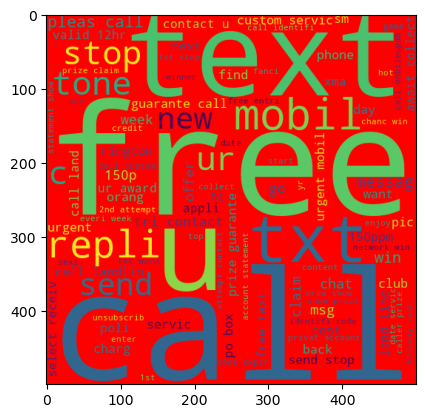

In [430]:
plt.imshow(img)

In [431]:
from collections import Counter

In [432]:
words=new_df["transform_text"].apply(lambda x:x.split())

In [433]:
w=[]
for i in words:
    for j in i:
        w.append(j)

In [434]:
len(w)

9939

In [435]:
from sklearn.feature_extraction.text import CountVectorizer,TfidfVectorizer

In [436]:
cv=CountVectorizer()
tt=TfidfVectorizer(max_features=3000)

In [437]:
x=tt.fit_transform(df["transform_text"]).toarray()

In [438]:
y=df["target"].values

In [439]:
from sklearn.model_selection import train_test_split

In [440]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=45)

In [441]:
from sklearn.naive_bayes import MultinomialNB,GaussianNB,BernoulliNB
from sklearn.metrics import accuracy_score,precision_score,confusion_matrix

In [442]:
mnb=MultinomialNB()
mnb=mnb.fit(x_train,y_train)
pred1=mnb.predict(x_test)
print(accuracy_score(y_test,pred1))
print(precision_score(y_test,pred1))
print(confusion_matrix(y_test,pred1))

0.9758220502901354
0.99
[[910   1]
 [ 24  99]]


In [443]:
gnb=GaussianNB()
gnb=gnb.fit(x_train,y_train)
pred2=gnb.predict(x_test)
print(accuracy_score(y_test,pred2))
print(precision_score(y_test,pred2))
print(confusion_matrix(y_test,pred2))

0.8752417794970987
0.48623853211009177
[[799 112]
 [ 17 106]]


In [444]:
bnb=BernoulliNB()
bnb=bnb.fit(x_train,y_train)
pred3=bnb.predict(x_test)
print(accuracy_score(y_test,pred3))
print(precision_score(y_test,pred3))
print(confusion_matrix(y_test,pred3))

0.9816247582205029
0.9727272727272728
[[908   3]
 [ 16 107]]


In [445]:
import numpy as np

In [448]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=1)
mnb=MultinomialNB()
mnb=mnb.fit(x_train,y_train)
pred1=mnb.predict(x_test)
print(accuracy_score(y_test,pred1))
print(precision_score(y_test,pred1))
print(confusion_matrix(y_test,pred1))

0.9613152804642167
1.0
[[899   0]
 [ 40  95]]


In [449]:
import joblib

In [450]:
joblib.dump(mnb,"model.pkl")

['model.pkl']

In [451]:
joblib.dump(tt,"vectorizer.pkl")

['vectorizer.pkl']